# Análisis del Agente MCTS — Reto Connect-4
**Laura Franco | Fundamentos de Inteligencia Artificial 2026.1**

Este notebook muetra el análisis del agente basado en Monte-Carlo Tree Search (MCTS) con selección UCT. Se evalúa el comportamiento del agente en función de otras variables como número de simulaciones, estrategias utilizadas, entre otros.

## 0. Setup e imports

In [8]:
import sys
import os
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

PROJECT_ROOT = os.path.abspath('../..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from connect4.connect_state import ConnectState
from connect4.policy import Policy
from groups.Laura.policy import mcts_uct
from groups.Laura.policy import MCTSAgent, HashableConnectState

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

seed = 42

## 1. Funciones auxiliares

In [9]:
class RandomAgent:
    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)

    def act(self, s: np.ndarray) -> int:
        cols = [c for c in range(7) if s[0, c] == 0]
        return int(self.rng.choice(cols))

def play_game(agent_red, agent_yellow, seed=None):
    state = ConnectState(None, -1)
    agents = {-1: agent_red, 1: agent_yellow}

    while not state.is_final():
        current_player = state.player
        action = agents[current_player].act(state.board)
        state = state.transition(int(action))

    return state.get_winner()

def run_games(agent_factory, opponent_factory, n_games=40, color=-1, seed=0):
    wins, draws, losses = 0, 0, 0
    for i in range(n_games):
        agent = agent_factory(seed=seed + i)
        opponent = opponent_factory(seed=seed + i + 1000)
        if color == -1:
            winner = play_game(agent, opponent)
        else:
            winner = play_game(opponent, agent)

        if winner == color:
            wins += 1
        elif winner == 0:
            draws += 1
        else:
            losses += 1

    return wins, draws, losses

def winrate(wins, draws, losses):
    total = wins + draws + losses
    return wins / total if total > 0 else 0

## 2. Tiempo por simulación

Se estimó cuanto tiempo se toma en promedio una simulación para manejar el tiempo de la mejor manera.

In [10]:
def agent_fns(player):
    def legal_actions_fn(state: ConnectState):
        return state.get_free_cols()

    def successor_fn(state: ConnectState, action: int, rng: np.random.RandomState):
        next_s = state.transition(action)
        return HashableConnectState(next_s.board, next_s.player)

    def terminal_fn(state: ConnectState):
        return state.is_final()

    def reward_fn(state: ConnectState):
        winner = state.get_winner()
        if winner == player:
            return 1
        elif winner == 0:
            return 0
        else:
            return -1

    return legal_actions_fn, successor_fn, terminal_fn, reward_fn

legal_actions_fn, successor_fn, terminal_fn, reward_fn = agent_fns(-1)

rng = np.random.RandomState(seed)
root_state = HashableConnectState(None, -1)

n_simulations = [10, 20, 30, 50, 70, 100, 150, 200]
t_sim = []

for n in n_simulations:
    start = time.time()
    mcts_analysis = mcts_uct(
                        root_state,
                        legal_actions_fn,
                        successor_fn,
                        terminal_fn,
                        reward_fn,
                        num_simulations=n,
                        max_depth=42,
                        exploration_c=math.sqrt(2),
                        rng=rng)
    t_total = time.time() - start
    t_sim.append(t_total / n)
    print(f'n={n:4d} sims → total: {t_total:.3f}s | por sim: {t_total/n*1000:.2f}ms')
    
t_sim_promedio = np.mean(t_sim)
print(f'\nPromedio tiempo por simulación: {t_sim_promedio*1000:.2f}ms')
print(f'Simulaciones posibles en 1s: ~{int(1/t_sim_promedio)}')

n=  10 sims → total: 0.531s | por sim: 53.08ms
n=  20 sims → total: 1.305s | por sim: 65.27ms
n=  30 sims → total: 2.171s | por sim: 72.37ms
n=  50 sims → total: 1.514s | por sim: 30.29ms
n=  70 sims → total: 1.882s | por sim: 26.88ms
n= 100 sims → total: 2.911s | por sim: 29.11ms
n= 150 sims → total: 4.940s | por sim: 32.94ms
n= 200 sims → total: 7.847s | por sim: 39.24ms

Promedio tiempo por simulación: 43.65ms
Simulaciones posibles en 1s: ~22


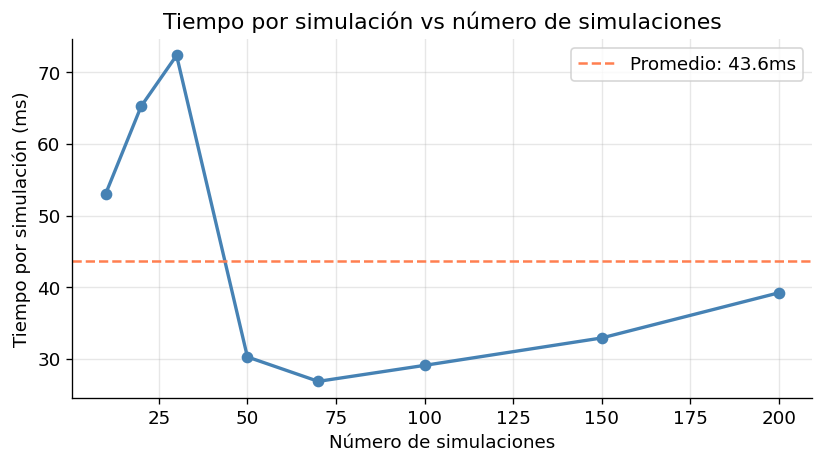

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_simulations, [t * 1000 for t in t_sim], 'o-', color='steelblue', linewidth=2)
ax.axhline(t_sim_promedio * 1000, color='coral', linestyle='--', label=f'Promedio: {t_sim_promedio*1000:.1f}ms')
ax.set_xlabel('Número de simulaciones')
ax.set_ylabel('Tiempo por simulación (ms)')
ax.set_title('Tiempo por simulación vs número de simulaciones')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Probabilidad de ganar según el número de simulaciones
Se evalúa el desempeño del agente dependiendo de cuantas simulaciones se lleven a cabo para estimar los Q_values antes de que el agente tome una decisión.

In [13]:
def make_mcts_agent(num_simulations, seed=seed):
    agent = MCTSAgent()
    agent.num_simulations = num_simulations
    agent.rng = np.random.RandomState(seed)
    return agent

n_sims = [1, 5, 10, 20, 30, 50, 100]
n_games = 60

results_red = []
results_yellow = []

for n in n_simulations:
    red_win, red_draw, red_loss = run_games(
        agent_factory=lambda seed, n=n: make_mcts_agent(n, seed=seed),
        opponent_factory=lambda seed: RandomAgent(seed=seed),
        n_games=n_games, color=-1
    )

    yellow_win, yellow_draw, yellow_loss = run_games(
        agent_factory=lambda seed, n=n: make_mcts_agent(n, seed=seed),
        opponent_factory=lambda seed: RandomAgent(seed=seed),
        n_games=n_games, color=1
    )

    results_red.append((red_win, red_draw, red_loss))
    results_yellow.append((yellow_win, yellow_draw, yellow_loss))
    print(f'rojo: {winrate(red_win,red_draw,red_loss):.0%} | amarillo: {winrate(yellow_win,yellow_draw,yellow_loss):.0%}')

win_rate_red    = [winrate(*r) for r in results_red]
win_rate_yellow = [winrate(*r) for r in results_yellow]

rojo: 98% | amarillo: 98%


KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_simulations, win_rate_red,    'o-', color='crimson',    linewidth=2, label='Rojo (va primero)')
ax.plot(n_simulations, win_rate_yellow, 's-', color='goldenrod',  linewidth=2, label='Amarillo (va segundo)')
ax.axhline(0.95, color='gray', linestyle='--', alpha=0.7, label='Umbral requerido (95%)')
ax.axhline(0.50, color='black', linestyle=':', alpha=0.4, label='50%')
ax.set_xlabel('Número de simulaciones MCTS')
ax.set_ylabel('Win-rate vs jugador aleatorio')
ax.set_title('Win-rate vs número de simulaciones')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

## 4. Impacto de las jugadas forzadas (forced_move y double_threat)
Se compara el desempeño del agente cuando fuerza movimiento vs cuando solo utiliza MCTS sin ninguna regla adicional. El desempeño se mide como la tasa o probabilidad estimada que tiene el agente de ganar.

In [ ]:
class MCTSAgentNotForced(MCTSAgent):
    def act(self, s: np.ndarray) -> int:
        player = self.current_player(s)
        root_state = HashableConnectState(s, player)

        if root_state.is_final():
            cols = root_state.get_free_cols()
            if cols:
                return cols[0]
            else: 
                return 0

        def legal_actions_fn(state: ConnectState):
            return state.get_free_cols()
        
        def successor_fn(state: ConnectState, action: int, rng: np.random.RandomState):
            next_s = state.transition(action)
            return HashableConnectState(next_s.board, next_s.player)

        def terminal_fn(state: ConnectState):
            return state.is_final()

        def reward_fn(state: ConnectState):
            winner = state.get_winner()
            if winner == player:
                return 1
            elif winner == 0:
                return 0
            else:
                return -1
            
        fichas_jugadas = int(np.sum(s != 0))
        max_depth = 42 - fichas_jugadas

        mcts_analysis = mcts_uct(
                            root_state,
                            legal_actions_fn,
                            successor_fn,
                            terminal_fn,
                            reward_fn,
                            num_simulations=self.num_simulations,
                            max_depth=42,
                            exploration_c=self.exploration_c,
                            rng=self.rng)

        best_a = mcts_analysis["best_action"]
        return best_a

n_games2 = 40
num_sims = 20

configs = {
    'Con jugadas forzadas': MCTSAgent,
    'Sin jugadas forzadas': MCTSAgentNotForced,
}

results_forced = {}
for name, AgentClass in configs.items():
    wr_r_list, wr_y_list = [], []
    for color, label in [(-1, 'rojo'), (1, 'amarillo')]:
        def factory(seed, cls=AgentClass):
            a = cls()
            a.num_simulations = num_sims
            a.rng = np.random.RandomState(seed)
            return a
        w, d, l = run_games(factory, lambda seed: RandomAgent(seed), n_games2, color)
        wr = w / (w + d + l)
        if color == -1: wr_r_list.append(wr)
        else: wr_y_list.append(wr)
        print(f'{name} | {label}: {wr:.0%} ({w}W {d}D {l}L)')
    results_forced[name] = (wr_r_list[0], wr_y_list[0])

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
labels = ['Rojo', 'Amarillo']
colors_bar = ['steelblue', 'coral']

for i, (name, (wr_r, wr_y)) in enumerate(results_forced.items()):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, [wr_r, wr_y], width, label=name, alpha=0.85)
    for bar, val in zip(bars, [wr_r, wr_y]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=10)

ax.axhline(0.95, color='gray', linestyle='--', alpha=0.7, label='Umbral 95%')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Win-rate vs jugador aleatorio')
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title(f'Impacto de jugadas forzadas (n_sims={num_sims})')
ax.legend()
plt.tight_layout()
plt.savefig('exp2_jugadas_forzadas.png', bbox_inches='tight')
plt.show()

## 5. Calidad de Q-values según el número de simulaciones
Se evalua si el MCTS conver a q-values estables al aumentar el número de simulaciones. Para esto, se analiza la varianza de los valores calculados en la raíz (q_root) a lo largo de múltiples ejecuciones independientes para diferentes presupuestos de simulación.

In [ ]:
def get_q_stats(num_simulations, n_runs=10, seed=seed):
    best_actions = []
    q_best_vals = []
    q_variances = []

    root = HashableConnectState(None, -1)
    player = -1
    legal_fn, succ_fn, term_fn, rew_fn = agent_fns(player)

    for i in range(n_runs):
        rng = np.random.RandomState(seed + i)
        result = mcts_uct(
                    root,
                    legal_fn,
                    succ_fn,
                    term_fn,
                    rew_fn,
                    num_simulations=num_simulations,
                    max_depth=42,
                    exploration_c=math.sqrt(2),
                    rng=rng)
        
        q_vals = list(result['q_root'].values())
        best_actions.append(result['best_action'])
        q_best_vals.append(max(q_vals) if q_vals else 0)
        q_variances.append(np.var(q_vals) if len(q_vals) > 1 else 0)

    return {
        'best_action_mode': max(set(best_actions), key=best_actions.count),
        'q_best_mean': np.mean(q_best_vals),
        'q_best_std': np.std(q_best_vals),
        'q_var_mean': np.mean(q_variances),
    }


SIM_Q = [25, 50, 100, 200, 300, 500, 1000]
q_stats = [get_q_stats(n, n_runs=15) for n in SIM_Q]

for n, s in zip(SIM_Q, q_stats):
    print(f'n={n:4d} | best_action={s["best_action_mode"]} | '
          f'Q_best={s["q_best_mean"]:.3f}±{s["q_best_std"]:.3f} | '
          f'Q_var={s["q_var_mean"]:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
means = [s['q_best_mean'] for s in q_stats]
stds  = [s['q_best_std']  for s in q_stats]
ax.errorbar(SIM_Q, means, yerr=stds, fmt='o-', color='steelblue',
            linewidth=2, capsize=5, label='Q_best ± std')
ax.set_xlabel('Número de simulaciones')
ax.set_ylabel('Q-value de la mejor acción')
ax.set_title('Convergencia del Q-value óptimo')
ax.legend()

ax = axes[1]
q_vars = [s['q_var_mean'] for s in q_stats]
ax.plot(SIM_Q, q_vars, 's-', color='coral', linewidth=2)
ax.set_xlabel('Número de simulaciones')
ax.set_ylabel('Varianza entre Q-values de acciones')
ax.set_title('Diferenciación entre acciones vs simulaciones')
ax.annotate('Mayor varianza = MCTS\ndistingue mejor las acciones',
            xy=(SIM_Q[-2], q_vars[-2]), xytext=(SIM_Q[1], max(q_vars)*0.9),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.suptitle('Calidad de Q-values vs número de simulaciones', y=1.02)
plt.tight_layout()
plt.show()

## 6. Desempeño contra agente con la misma estrategia

In [ ]:
def play_self(n_sims, n_games=30, seed=seed):
    red_wins, yellow_wins, draws = 0, 0, 0
    for i in range(n_games):
        agent_r = MCTSAgent()
        agent_r.num_simulations = n_sims
        agent_r.rng = np.random.RandomState(seed + i)

        agent_y = MCTSAgent()
        agent_y.num_simulations = n_sims
        agent_y.rng = np.random.RandomState(seed + i + 500)

        winner = play_game(agent_r, agent_y)
        if winner == -1:
            red_wins += 1
        elif winner == 1:
            yellow_wins += 1
        else:
            draws += 1

    return red_wins, yellow_wins, draws


SIM_SELF = [10, 20, 30, 50, 70, 100, 150, 200]
self_results = {}

for n in SIM_SELF:
    r, y, d = play_self(n, n_games=30)
    self_results[n] = (r, y, d)
    total = r + y + d
    print(f'n={n:3d} sims | Rojo: {r/total:.0%} | Amarillo: {y/total:.0%} | Empates: {d/total:.0%}')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(SIM_SELF))
width = 0.25

reds    = [self_results[n][0] / sum(self_results[n]) for n in SIM_SELF]
yellows = [self_results[n][1] / sum(self_results[n]) for n in SIM_SELF]
draws_p = [self_results[n][2] / sum(self_results[n]) for n in SIM_SELF]

ax.bar(x - width, reds, width, label='Rojo gana', color='crimson', alpha=0.8)
ax.bar(x, yellows, width, label='Amarillo gana', color='goldenrod', alpha=0.8)
ax.bar(x + width, draws_p, width, label='Empate', color='lightgray', alpha=0.8)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% (juego perfecto)')
ax.set_xticks(x)
ax.set_xticklabels([f'n={n}' for n in SIM_SELF])
ax.set_ylabel('Proporción de resultados')
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('MCTS vs sí mismo')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Propuesta de mejoras